**Workflow**

Set Google Colab Runtime type to GPU, check if GPU is being used with !nvidia-smi command.

1. Load a Huggingface construction vehicle dataset, split it into train and test sets
   * Display the contents of a sample from the dataset
   * Load the image from the sample and corresponding annotation
   * Display the image overlaid with object annotation
   * Convert class names to numerical labels
   * Print the object class names present in the dataset

* Note: Steps 2-4 are common workflow steps for Hugging Face DETR models
2. Preprocess the dataset and apply transforms
   * Resize the data to apply data augmentations.
   * Format annotations to convert them to Coco compatible ones
   * Load a Transformer based object detection model check point (for DETR)
   * Instantiate an image processor using the checkpoint
   * Append images and annotations into lists and pass them through the image processor

3.  Batch images and masks
    * Write a function to put batches of images together.
    * Add padding to images corresponding to the largest image in a batch
    * Create a corresponding pixel_mask to distinguish between real pixels (1) and padding (0).

4. Load and train a DETR model for detection of construction vehicles
    * Load the model with AutoModelForObjectDetection using the same checkpoint used in the preprocessing.
    * Define training hyperparameters
    * Pass the training arguments to Trainer
    * Compile model, add callbacks, and run the training
    * (Optional) Upload the trained model to Huggingface hub

6. Evaluate model and run inference
    * Format annotations for the test dataset
    * Save images and annotations into the expected format for torchvision.datasets.CocoDetection
    * Prepare an instance of a CocoDetection class that can be used with cocoevaluator.
    * Load metrics and run the evaluation.
    * Load an image from the test dataset
    * Run inference on the image using the trained model
    * Display predicted object bounding boxes overlaid on the image with object class


In [ ]:
!nvidia-smi

Wed Dec 27 14:51:27 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   71C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip install -q datasets evaluate timm albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.8 MB/s eta 0:00:00


In [ ]:
!pip install transformers==4.31.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 17.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.0
    Uninstalling tokenizers-0.15.0:
      Successfully uninstalled tokenizers-0.15.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.35.2
    Uninstalling transformers-4.35.2:
      Successfully uninstalled transformers-4.35.2


In [ ]:
# Load necessary libraries
from datasets import load_dataset

# Load the dataset
ds = load_dataset("keremberke/excavator-detector", name="full")

# Retrieve an example from the training set
example = ds['train'][0]



In [ ]:
#Print dataset contents
ds

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 2245
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 267
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 144
    })
})

In [ ]:
#Print contents of 1 sample from the dataset
example

{'image_id': 714,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640>,
 'width': 640,
 'height': 640,
 'objects': {'id': [1001, 1002, 1003],
  'area': [15876, 6530, 108117],
  'bbox': [[257.0, 58.0, 126.0, 126.0],
   [168.0, 0.0, 86.5, 75.5],
   [87.0, 246.0, 293.0, 369.0]],
  'category': [1, 1, 2]}}

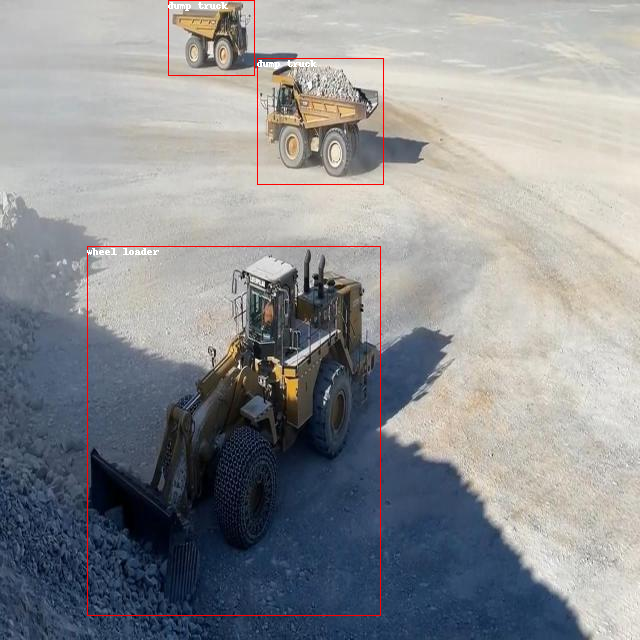

In [ ]:
# Import necessary libraries
import numpy as np
import os
from PIL import Image, ImageDraw

# Retrieve an image and its annotations from the dataset
image = ds["train"][0]["image"]
annotations = ds["train"][0]["objects"]

# Create an ImageDraw object to draw on the image
draw = ImageDraw.Draw(image)

# Retrieve the categories from the dataset
categories = ds["train"].features["objects"].feature["category"].names

# Create mappings between category indices and labels
id2label = {index: x for index, x in enumerate(categories, start=0)}
label2id = {v: k for k, v in id2label.items()}

# Draw bounding boxes and labels on the image
for i in range(len(annotations["id"])):
    box = annotations["bbox"][i - 1]
    class_idx = annotations["category"][i - 1]
    x, y, w, h = tuple(box)
    draw.rectangle((x, y, x + w, y + h), outline="red", width=1)
    draw.text((x, y), id2label[class_idx], fill="white")

# Display the annotated image
image


In [ ]:
# Check the meaning of labels in dataset
id2label

{0: 'excavators', 1: 'dump truck', 2: 'wheel loader'}

In [ ]:
# Import AutoImageProcessor from transformers
from transformers import AutoImageProcessor

# Specify the checkpoint for the DETR model with ResNet-50 backbone
checkpoint = "facebook/detr-resnet-50"

# Instantiate an AutoImageProcessor from the specified checkpoint
image_processor = AutoImageProcessor.from_pretrained(checkpoint)


Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [ ]:
# Import necessary libraries
import albumentations
import numpy as np
import torch

# Define the transformation using Albumentations
transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


In [ ]:
def formatted_anns(image_id, category, area, bbox):
    """
    Format annotations for the given image.

    Args:
        image_id (int): Image ID.
        category (list): List of category IDs.
        area (list): List of areas.
        bbox (list): List of bounding boxes.

    Returns:
        list: Formatted list of annotations.
    """
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations


In [ ]:
# transforming a batch
def transform_aug_ann(examples):
    """
    Transform and augment the given examples.

    Args:
        examples (dict): Dictionary containing image and object information.

    Returns:
        dict: Transformed and augmented examples.
    """
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")


In [ ]:
ds["train"] = ds["train"].with_transform(transform_aug_ann)
ds["train"][15]




{'pixel_values': tensor([[[-1.0904, -1.0562, -1.0219,  ..., -0.1999, -0.1999, -0.1999],
          [-1.1075, -1.0733, -1.0390,  ..., -0.1999, -0.1999, -0.1999],
          [-1.1247, -1.1075, -1.0733,  ..., -0.1999, -0.1999, -0.1999],
          ...,
          [-0.5082, -0.5596, -0.6281,  ..., -0.1828, -0.1657, -0.1486],
          [-0.5253, -0.5767, -0.6623,  ..., -0.1999, -0.1828, -0.1657],
          [-0.5424, -0.5938, -0.6794,  ..., -0.1999, -0.1828, -0.1657]],
 
         [[-1.4755, -1.4580, -1.4230,  ..., -1.2829, -1.2829, -1.2829],
          [-1.4930, -1.4755, -1.4405,  ..., -1.2829, -1.2829, -1.2829],
          [-1.5105, -1.4930, -1.4755,  ..., -1.2829, -1.2829, -1.2829],
          ...,
          [ 0.0301, -0.0224, -0.0924,  ...,  0.3803,  0.3978,  0.4153],
          [ 0.0126, -0.0399, -0.1275,  ...,  0.3627,  0.3803,  0.3978],
          [-0.0049, -0.0574, -0.1450,  ...,  0.3627,  0.3803,  0.3803]],
 
         [[-1.4559, -1.4210, -1.3861,  ..., -1.8044, -1.8044, -1.8044],
          [-

In [ ]:
def collate_fn(batch):
    # Extract pixel values from each item in the batch
    pixel_values = [item["pixel_values"] for item in batch]

    # Pad the pixel values using the image processor
    encoding = image_processor.pad(pixel_values, return_tensors="pt")

    # Extract labels from each item in the batch
    labels = [item["labels"] for item in batch]

    # Construct the batch dictionary
    batch = {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": labels
    }

    return batch


In [ ]:
# Define the model
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Some weights of DetrForObjectDetection were not initialized from the model checkpoint at facebook/detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.weight: found shape torch.Size([92, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- class_labels_classifier.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
## hub login
from huggingface_hub import login
login(token='Your token')


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [ ]:
!pip install accelerate -U

In [ ]:
import accelerate

accelerate.__version__

'0.25.0'

In [ ]:
# Set hyperparameters
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="detr-resnet-50_machinery-I",
    per_device_train_batch_size=8,
    num_train_epochs=10,
    fp16=True,
    save_steps=20,
    logging_steps=10,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=True,
)

In [ ]:
#Start training
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,
    data_collator=collate_fn,
    train_dataset=ds["train"],
    tokenizer=image_processor,
)

trainer.train()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_deprecation.py:127: FutureWarning: 'Repository' (from 'huggingface_hub.repository') is deprecated and will be removed from version '1.0'. Please prefer the http-based alternatives instead. Given its large adoption in legacy code, the complete removal is only planned on next major release.
For more details, please read https://huggingface.co/docs/huggingface_hub/concepts/git_vs_http.
  warnings.warn(warning_message, FutureWarning)
/content/detr-resnet-50_machinery-I is already a clone of https://huggingface.co/akar49/detr-resnet-50_machinery-I. Make sure you pull the latest changes with `repo.git_pull()`.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
10,0.906100
20,0.919800
30,0.981900
40,1.009900
50,1.084200
60,1.070400
70,0.954800
80,1.182900
90,0.941400
100,0.876000


TrainOutput(global_step=2810, training_loss=0.750741156819028, metrics={'train_runtime': 6248.8075, 'train_samples_per_second': 3.593, 'train_steps_per_second': 0.45, 'total_flos': 1.0728818016768e+19, 'train_loss': 0.750741156819028, 'epoch': 10.0})

In [ ]:
# Upload trained model to Huggingface Hub
trainer.push_to_hub()

Upload file pytorch_model.bin:   0%|          | 1.00/159M [00:00<?, ?B/s]

Upload file runs/Dec27_15-51-11_850497e1fb94/events.out.tfevents.1703692278.850497e1fb94.2674.1:   0%|        …

To https://huggingface.co/akar49/detr-resnet-50_machinery-I
   dc62f95..1f17623  main -> main

   dc62f95..1f17623  main -> main

To https://huggingface.co/akar49/detr-resnet-50_machinery-I
   1f17623..dc4a489  main -> main

   1f17623..dc4a489  main -> main



'https://huggingface.co/akar49/detr-resnet-50_machinery-I/commit/1f17623b2ce7921ce4c58fcfca786eecb509a1d6'

In [ ]:
# Import necessary modules
import json

# Define a function to format annotations for validation
def val_formatted_anns(image_id, objects):
    annotations = []
    for i in range(0, len(objects["id"])):
        new_ann = {
            "id": objects["id"][i],
            "category_id": objects["category"][i],
            "iscrowd": 0,
            "image_id": image_id,
            "area": objects["area"][i],
            "bbox": objects["bbox"][i],
        }
        annotations.append(new_ann)

    return annotations

# Define a function to save images and annotations into the files expected by torchvision.datasets.CocoDetection
def save_annotation_file_images(dataset):
    output_json = {}
    path_output = f"{os.getcwd()}/machinery/"

    if not os.path.exists(path_output):
        os.makedirs(path_output)

    path_anno = os.path.join(path_output, "machine_ann.json")
    categories_json = [{"supercategory": "none", "id": id, "name": id2label[id]} for id in id2label]
    output_json["images"] = []
    output_json["annotations"] = []

    # Iterate through examples in the dataset
    for example in dataset:
        ann = val_formatted_anns(example["image_id"], example["objects"])
        output_json["images"].append(
            {
                "id": example["image_id"],
                "width": example["image"].width,
                "height": example["image"].height,
                "file_name": f"{example['image_id']}.png",
            }
        )
        output_json["annotations"].extend(ann)

    output_json["categories"] = categories_json

    # Save the JSON file
    with open(path_anno, "w") as file:
        json.dump(output_json, file, ensure_ascii=False, indent=4)

    # Save each image
    for im, img_id in zip(ds["test"]["image"],ds["test"]["image_id"]):
       path_img = os.path.join(path_output, f"{img_id}.png")
       im.save(path_img)

    return path_output, path_anno


In [ ]:
# Define a custom dataset class for COCO-style detection with additional processing
import torchvision

class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, image_processor, ann_file):
        super().__init__(img_folder, ann_file)
        self.image_processor = image_processor

    def __getitem__(self, idx):
        # Read in PIL image and target in COCO format
        img, target = super(CocoDetection, self).__getitem__(idx)

        # Preprocess image and target: converting target to DETR format,
        # resizing + normalization of both image and target)
        image_id = self.ids[idx]
        target = {"image_id": image_id, "annotations": target}
        encoding = self.image_processor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()  # Remove batch dimension
        target = encoding["labels"][0]  # Remove batch dimension

        return {"pixel_values": pixel_values, "labels": target}

# Create an instance of AutoImageProcessor for image processing
im_processor = AutoImageProcessor.from_pretrained("Your model")

# Save COCO-style annotation file for the test dataset
path_output, path_anno = save_annotation_file_images(ds["test"])

# Create an instance of the custom dataset class using COCO-style annotations
test_ds_coco_format = CocoDetection(path_output, im_processor, path_anno)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
# Import necessary modules
import evaluate
from tqdm import tqdm

# Load the pre-trained object detection model
model = AutoModelForObjectDetection.from_pretrained("your model")

# Load the COCO evaluation module
module = evaluate.load("ybelkada/cocoevaluate", coco=test_ds_coco_format.coco)

# Create a DataLoader for the validation dataset
val_dataloader = torch.utils.data.DataLoader(
    test_ds_coco_format, batch_size=8, shuffle=False, num_workers=4, collate_fn=collate_fn
)

# Perform evaluation on the validation dataset
with torch.no_grad():
    for idx, batch in enumerate(tqdm(val_dataloader)):
        pixel_values = batch["pixel_values"]
        pixel_mask = batch["pixel_mask"]

        labels = [
            {k: v for k, v in t.items()} for t in batch["labels"]
        ]  # These are in DETR format, resized + normalized

        # Forward pass
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        orig_target_sizes = torch.stack([target["orig_size"] for target in labels], dim=0)
        results = im_processor.post_process(outputs, orig_target_sizes)  # Convert model outputs to COCO API format

        # Add predictions and references to the evaluation module
        module.add(prediction=results, reference=labels)
        del batch

# Compute and print evaluation results
results = module.compute()
print(results)


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
100%|██████████| 18/18 [08:41<00:00, 29.00s/it]


Accumulating evaluation results...
DONE (t=0.16s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.237
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.302
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.265
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.257
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.506
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.666
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.713
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.310
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= 

In [ ]:
# Select a test image
image = ds["test"][16]["image"]

In [ ]:
# Load image processor and object detection model from pretrained checkpoints
image_processor = AutoImageProcessor.from_pretrained("your model")
model = AutoModelForObjectDetection.from_pretrained("your model")

# Perform inference on the input image
with torch.no_grad():
    # Preprocess the image using the image processor
    inputs = image_processor(images=image, return_tensors="pt")

    # Forward pass through the object detection model
    outputs = model(**inputs)

    # Specify target sizes for post-processing
    target_sizes = torch.tensor([image.size[::-1]])

    # Post-process the outputs to obtain detection results
    results = image_processor.post_process_object_detection(outputs, threshold=0.4, target_sizes=target_sizes)[0]

# Print the detected objects with their confidence scores and bounding box coordinates
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )


Detected dump truck with confidence 0.471 at location [64.49, 164.5, 261.89, 368.8]


In [ ]:
# Display the results
results

{'scores': tensor([0.4705]),
 'labels': tensor([1]),
 'boxes': tensor([[ 64.4854, 164.5018, 261.8902, 368.8036]])}

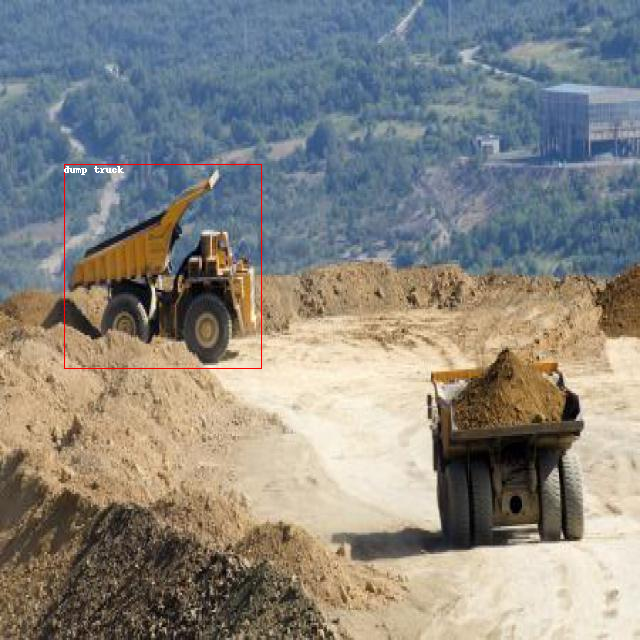

In [ ]:
# Create a drawing object to visualize the detection results on the input image
draw = ImageDraw.Draw(image)

# Iterate over the detected objects and draw bounding boxes and labels
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)

    # Draw a bounding box around the detected object
    draw.rectangle((x, y, x2, y2), outline="red", width=1)

    # Display the label on the top-left corner of the bounding box
    draw.text((x, y), model.config.id2label[label.item()], fill="white")

# Display the image with bounding boxes and labels
image
